# Research Question
**Can squirrel behaviour patterns predict whether a squirrel will approach humans in Central Park?**


---
# Section 1: Preprocessing

Data cleaning, handling missing values, encoding, and producing `squirrel_merged.csv` for downstream analysis.

In [1]:
import pandas as pd
import numpy as np

# Load raw data
sq = pd.read_csv('squirrel.csv')
hc = pd.read_csv('hectare.csv')

print(f"[Load] squirrel.csv: {sq.shape}")
print(f"[Load] hectare.csv:  {hc.shape}")

[Load] squirrel.csv: (3023, 31)
[Load] hectare.csv:  (700, 13)


In [2]:
# Drop high-missingness and redundant columns
drop_cols = [
    'Color notes', 'Specific Location', 'Other Activities', 'Other Interactions',
    'Unique Squirrel ID', 'Lat/Long', 'Combination of Primary and Highlight Color',
    'Hectare Squirrel Number',
]
sq.drop(columns=drop_cols, inplace=True)

In [3]:
# Impute missing values

sq['Age'] = sq['Age'].replace('?', np.nan).fillna(sq['Age'].mode()[0])

sq['Primary Fur Color'] = sq['Primary Fur Color'].fillna(sq['Primary Fur Color'].mode()[0])

sq['Highlight Fur Color'] = sq['Highlight Fur Color'].fillna('None')

sq['Location'] = sq['Location'].fillna(sq['Location'].mode()[0])

sq['Above Ground Sighter Measurement'] = (
    sq['Above Ground Sighter Measurement'].replace('FALSE', '0').fillna('0').astype(float)
)

sq['Date'] = pd.to_datetime(sq['Date'].astype(str).str.zfill(8), format='%m%d%Y')

print("[squirrel] Missing values remaining:", sq.isnull().sum().sum())
print(f"[squirrel] Final shape: {sq.shape}")

[squirrel] Missing values remaining: 0
[squirrel] Final shape: (3023, 23)


In [4]:
# Clean hectare.csv
hc.drop(columns=['Litter Notes', 'Hectare Conditions Notes', 'Litter'], inplace=True)

hc['Sighter Observed Weather Data'] = hc['Sighter Observed Weather Data'].fillna(
    hc['Sighter Observed Weather Data'].mode()[0])
hc['Other Animal Sightings'] = hc['Other Animal Sightings'].fillna('None')
hc['Total Time of Sighting'] = hc['Total Time of Sighting'].fillna(
    hc['Total Time of Sighting'].median())
hc['Date'] = pd.to_datetime(hc['Date'].astype(str).str.zfill(8), format='%m%d%Y')

print("[hectare] Missing values remaining:", hc.isnull().sum().sum())
print(f"[hectare] Final shape: {hc.shape}")

[hectare] Missing values remaining: 40
[hectare] Final shape: (700, 10)


In [5]:
# Merge: add Hectare_Squirrel_Count feature
hc_feature = (hc[['Hectare', 'Shift', 'Date', 'Number of Squirrels']]
              .rename(columns={'Number of Squirrels': 'Hectare_Squirrel_Count'}))
sq_merged = sq.merge(hc_feature, on=['Hectare', 'Shift', 'Date'], how='left')
sq_merged['Hectare_Squirrel_Count'] = sq_merged['Hectare_Squirrel_Count'].fillna(
    sq_merged['Hectare_Squirrel_Count'].median())

sq_merged.to_csv('squirrel_merged.csv', index=False)
print(f"[Output] squirrel_merged.csv — {sq_merged.shape[0]} rows, {sq_merged.shape[1]} cols")
sq_merged.head()

[Output] squirrel_merged.csv — 3023 rows, 24 cols


,X,Y,Hectare,Shift,Date,Age,Primary Fur Color,Highlight Fur Color,Location,Above Ground Sighter Measurement,...,Foraging,Kuks,Quaas,Moans,Tail flags,Tail twitches,Approaches,Indifferent,Runs from,Hectare_Squirrel_Count
0,-73.956134,40.794082,37F,PM,2018-10-14,Adult,Gray,None,Ground Plane,0.0,...,False,False,False,False,False,False,False,False,False,3.0
1,-73.968857,40.783783,21B,AM,2018-10-19,Adult,Gray,None,Ground Plane,0.0,...,False,False,False,False,False,False,False,False,False,7.0
2,-73.974281,40.775534,11B,PM,2018-10-14,Adult,Gray,None,Above Ground,10.0,...,False,False,False,False,False,False,False,False,False,8.0
3,-73.959641,40.790313,32E,PM,2018-10-17,Adult,Gray,None,Ground Plane,0.0,...,True,False,False,False,False,False,False,False,True,16.0
4,-73.970268,40.776213,13E,AM,2018-10-17,Adult,Gray,Cinnamon,Above Ground,0.0,...,True,False,False,False,False,False,False,False,False,13.0


---
# Section 2: Correlation Analysis

Mutual Information and Pearson correlation to identify which behavioural features are most associated with `Approaches`.

In [6]:
# Import libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import tools for feature analysis
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Load dataset
squirrel_data = pd.read_csv('squirrel_merged.csv')

In [7]:
# Define different types of feature columns
bool_features = ['Running','Chasing','Climbing','Eating','Foraging',
             'Kuks','Quaas','Moans','Tail flags','Tail twitches',
             'Indifferent','Runs from']
categorical_features  = ['Age','Primary Fur Color','Location','Shift']
numerical_features  = ['Above Ground Sighter Measurement','Hectare_Squirrel_Count']

# Check target variable distribution (supports class imbalance discussion)
print("Target variable distribution:")
print(squirrel_data['Approaches'].value_counts())
print()

# Encode for MI calculation
encoded_features = squirrel_data[bool_features + categorical_features + numerical_features].copy()
for col in bool_features:
    encoded_features[col] = encoded_features[col].astype(int)
for col in categorical_features:
    encoded_features[col] = LabelEncoder().fit_transform(encoded_features[col].astype(str))

# Handle missing values to prevent mutual_info_classif errors
encoded_features = encoded_features.fillna(0)

# Set the target variable
target_var = squirrel_data['Approaches'].astype(int)

Target variable distribution:
Approaches
False    2845
True      178
Name: count, dtype: int64



Top 5 features by Mutual Information Score:
                         Feature  MI Score
                     Indifferent  0.020127
Above Ground Sighter Measurement  0.012829
                        Location  0.004719
               Primary Fur Color  0.003208
                       Runs from  0.002603



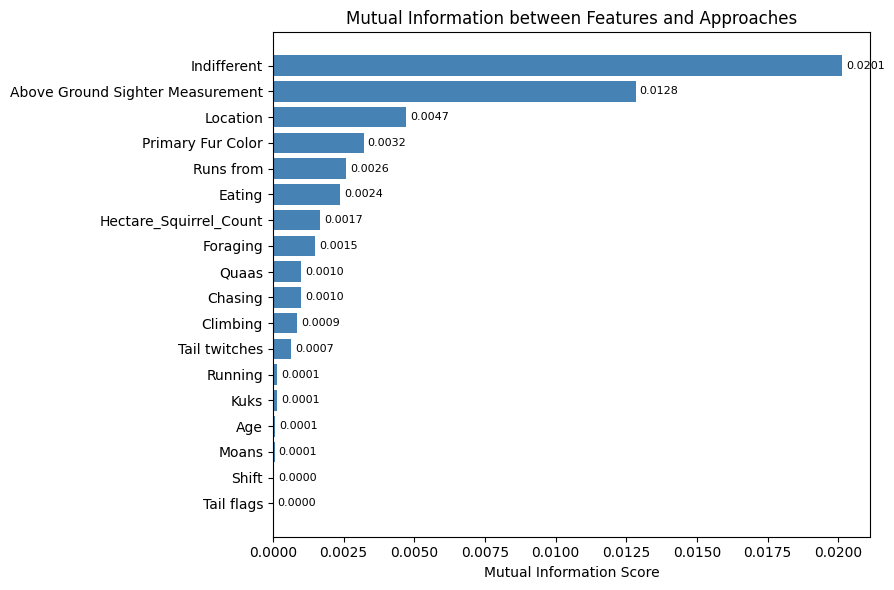

In [8]:
# Calculate mutual information and plot bar chart
# Identify discrete and continuous features
is_discrete_feature = (
    [True] * len(bool_features) +
    [True] * len(categorical_features) +
    [False] * len(numerical_features)
)

# Calculate mutual information scores for each feature
mutual_info_scores = mutual_info_classif(
    encoded_features,
    target_var,
    discrete_features=is_discrete_feature,
    random_state=42
)

# Create a table of feature MI scores, sort by score ascending
mutual_info_df = pd.DataFrame({
    'Feature': encoded_features.columns,
    'MI Score': mutual_info_scores
})
mutual_info_df = mutual_info_df.sort_values('MI Score', ascending=True)

# Print top 5 features by MI score (useful for report)
print("Top 5 features by Mutual Information Score:")
print(mutual_info_df.sort_values('MI Score', ascending=False).head(5).to_string(index=False))
print()

# Plot a horizontal bar chart
plt.figure(figsize=(9, 6))
bars = plt.barh(mutual_info_df['Feature'], mutual_info_df['MI Score'], color='steelblue')
plt.xlabel('Mutual Information Score')
plt.title('Mutual Information between Features and Approaches')
plt.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig('mutual_info.png', dpi=150, bbox_inches='tight')
plt.show()

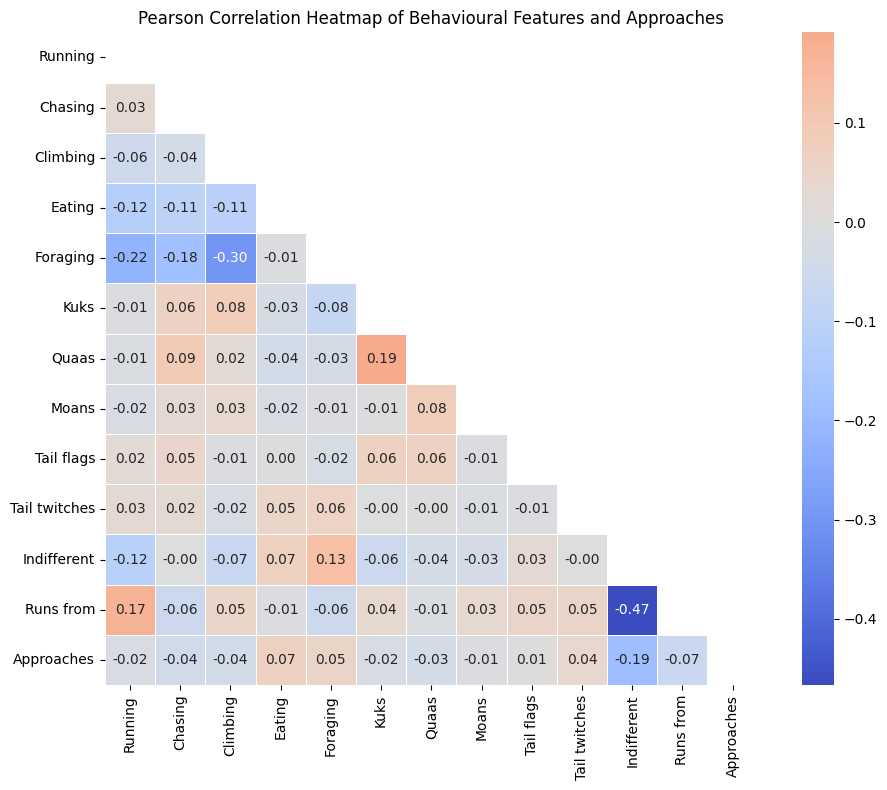

In [9]:
# Pearson Correlation Heatmap (behavioural features only)
behavior_features_with_target = bool_features + ['Approaches']
behavior_data = squirrel_data[behavior_features_with_target].astype(int)

# Handle missing values
behavior_data = behavior_data.fillna(0)

# Calculate Pearson correlation matrix
correlation_matrix = behavior_data.corr()

# Display only lower half, avoid redundancy
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Plot a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Pearson Correlation Heatmap of Behavioural Features and Approaches')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Section 3: Supervised Learning



Build up and compare two classifiers : K-Nearest Neighbours (KNN) and Decision Tree  to predict `Approaches`.

In [10]:
import pandas as pd        
import numpy as np         
import matplotlib.pyplot as plt  

# Classifiers
from sklearn.neighbors import KNeighborsClassifier     
from sklearn.tree import DecisionTreeClassifier, plot_tree  

# Model utilities
from sklearn.model_selection import train_test_split    
from sklearn.preprocessing import StandardScaler        

# 4 Evaluation metrics: accuracy, precision, recall and F1 score
from sklearn.metrics import (
    accuracy_score,          
    confusion_matrix,        
    ConfusionMatrixDisplay, 
    recall_score,            
    precision_score,         
    f1_score                 
)

# Handle class imbalance by oversampling the minority class in the training set
from imblearn.over_sampling import RandomOverSampler

In [11]:
# Load preprocessed data
df = pd.read_csv('squirrel_merged.csv')

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (3023, 24)


,X,Y,Hectare,Shift,Date,Age,Primary Fur Color,Highlight Fur Color,Location,Above Ground Sighter Measurement,...,Foraging,Kuks,Quaas,Moans,Tail flags,Tail twitches,Approaches,Indifferent,Runs from,Hectare_Squirrel_Count
0,-73.956134,40.794082,37F,PM,2018-10-14,Adult,Gray,NaN,Ground Plane,0.0,...,False,False,False,False,False,False,False,False,False,3.0
1,-73.968857,40.783783,21B,AM,2018-10-19,Adult,Gray,NaN,Ground Plane,0.0,...,False,False,False,False,False,False,False,False,False,7.0
2,-73.974281,40.775534,11B,PM,2018-10-14,Adult,Gray,NaN,Above Ground,10.0,...,False,False,False,False,False,False,False,False,False,8.0
3,-73.959641,40.790313,32E,PM,2018-10-17,Adult,Gray,NaN,Ground Plane,0.0,...,True,False,False,False,False,False,False,False,True,16.0
4,-73.970268,40.776213,13E,AM,2018-10-17,Adult,Gray,Cinnamon,Above Ground,0.0,...,True,False,False,False,False,False,False,False,False,13.0


Class distribution (before oversampling):
Approaches
False    2845
True      178
Name: count, dtype: int64


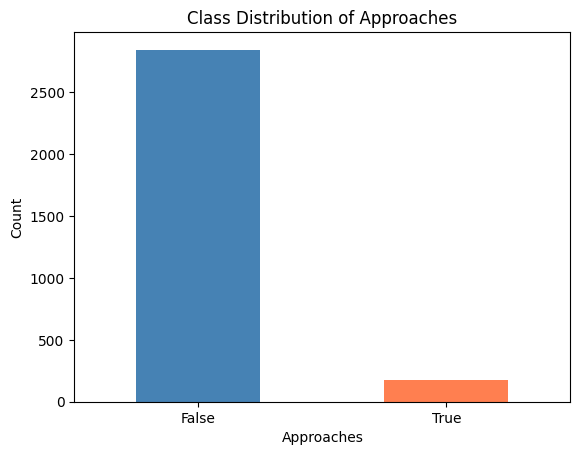

In [12]:
# ── Feature Selection & Target Definition ─────────────────
# Behavioural features informed by Section 2 MI analysis

FEATURE_COLS = [
    'Running', 'Chasing', 'Climbing', 'Eating', 'Foraging',
    'Kuks', 'Quaas', 'Moans', 'Tail flags', 'Tail twitches',
    'Indifferent', 'Runs from'
]
TARGET_COL = 'Approaches'

X = df[FEATURE_COLS]   # Feature matrix
y = df[TARGET_COL]     # Target variable (binary check either True/False)

# ── Class Distribution Check ──────────────────────────────
# Visualise imbalance before oversampling 
print('Class distribution (before oversampling):')
print(y.value_counts())

y.value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Class Distribution of Approaches')
plt.xlabel('Approaches')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [13]:
# ── Train/Test Split (80/20) ──────────────────────────────
# Split before oversampling to ensure the test set reflects

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42
)

# Verify split sizes and class distribution in each set
print('Training set size:', X_train.shape[0])   
print('Test set size:    ', X_test.shape[0])     
print('\nDistribution of train classes:')
print(pd.Series(y_train).value_counts())        
print('\nDistribution of test classes:')
print(pd.Series(y_test).value_counts())          

Training set size: 2418
Test set size:     605

Distribution of train classes:
Approaches
False    2271
True      147
Name: count, dtype: int64

Distribution of test classes:
Approaches
False    574
True      31
Name: count, dtype: int64


In [14]:
# ── Handle Class Imbalance ────────────────────────────────
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

# Both classes should now be equal 
print('After oversampling (training set only):')
print(pd.Series(y_train_res).value_counts())

After oversampling (training set only):
Approaches
False    2271
True     2271
Name: count, dtype: int64


In [15]:
# ── K-Nearest Neighbours (KNN) ────────────────────────────
# KNN predicts based on the 5 closest training samples.
# Scaling is required because KNN uses distance.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)  # fit on train only
X_test_scaled  = scaler.transform(X_test)           # apply same scale to test

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_res)
y_pred_knn = knn.predict(X_test_scaled)

print('KNN Results:')
print('Accuracy: ', round(accuracy_score(y_test, y_pred_knn), 2))
print('Precision:', round(precision_score(y_test, y_pred_knn), 2))
print('Recall:   ', round(recall_score(y_test, y_pred_knn), 2))
print('F1 Score: ', round(f1_score(y_test, y_pred_knn), 2))

KNN Results:
Accuracy:  0.94
Precision: 0.31
Recall:    0.13
F1 Score:  0.18


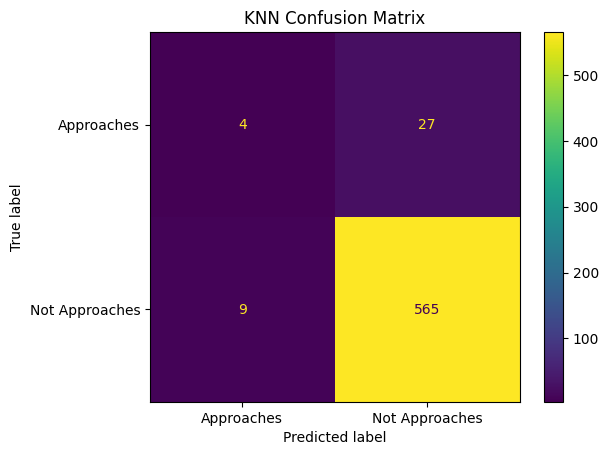

In [16]:
# ── KNN confusion matrix────────────────────────────
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=[True, False])
ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                       display_labels=['Approaches', 'Not Approaches']).plot()
plt.title('KNN Confusion Matrix')
plt.show()

In [17]:
# ── Decision Tree────────────────────────────
# No scaling needed and DT splits on thresholds, not distances
# max_depth=4 prevents overfitting to training data
dt = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
dt.fit(X_train_res, y_train_res)
y_pred_dt = dt.predict(X_test)

print('Decision Tree Results:')
print('Accuracy: ', round(accuracy_score(y_test, y_pred_dt), 2))
print('Precision:', round(precision_score(y_test, y_pred_dt), 2))
print('Recall:   ', round(recall_score(y_test, y_pred_dt), 2))
print('F1 Score: ', round(f1_score(y_test, y_pred_dt), 2))

Decision Tree Results:
Accuracy:  0.68
Precision: 0.12
Recall:    0.77
F1 Score:  0.2


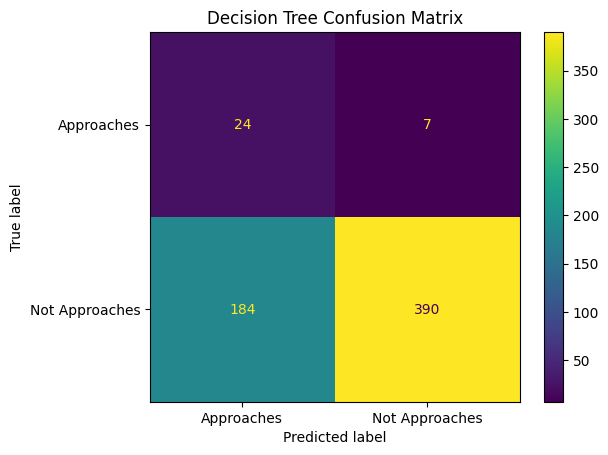

In [18]:
 # ── Decision Tree Confusion Matrix ────────────────────────────

cm_dt = confusion_matrix(y_test, y_pred_dt, labels=[True, False])
ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                       display_labels=['Approaches', 'Not Approaches']).plot()
plt.title('Decision Tree Confusion Matrix')
plt.show()

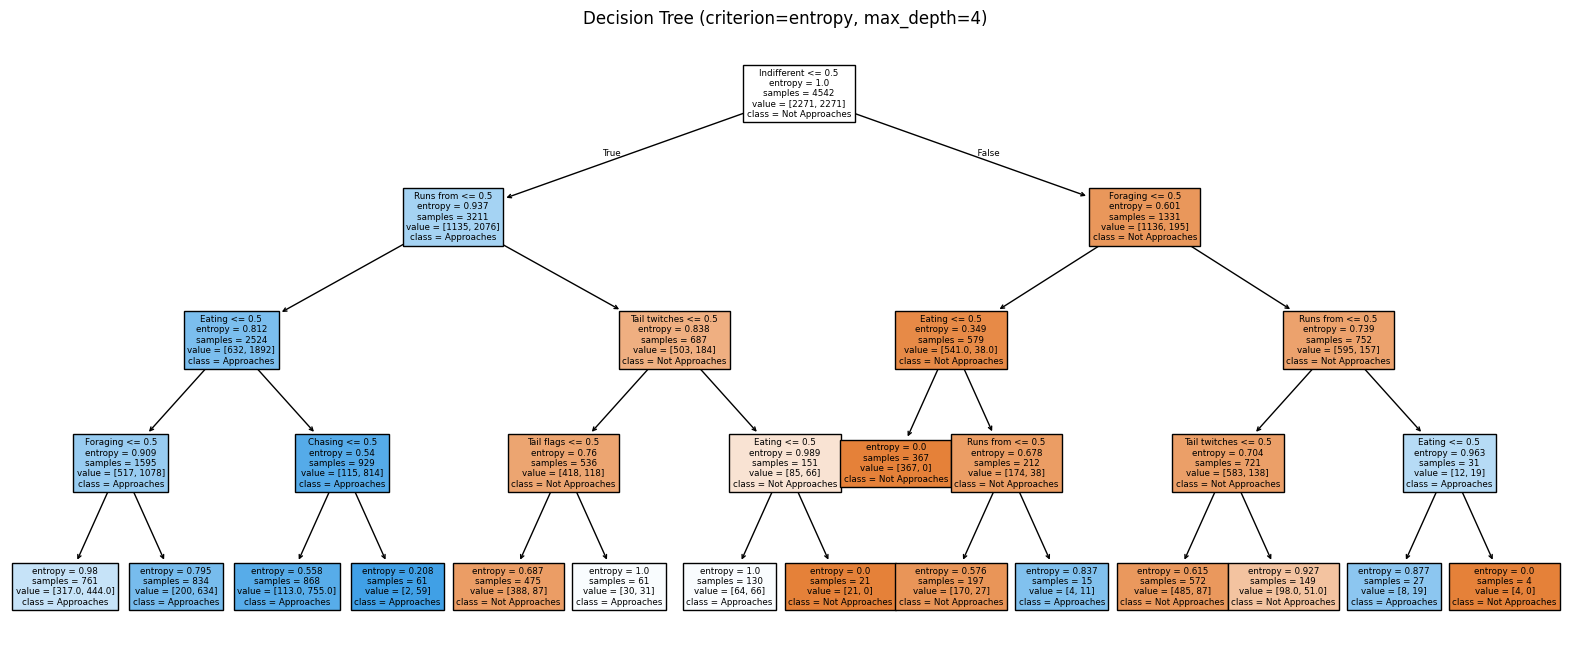

In [19]:
 # ── # Decision Tree Visualisation ────────────────────────────


plt.figure(figsize=(20, 8))
plot_tree(dt, feature_names=FEATURE_COLS,
          class_names=['Not Approaches', 'Approaches'], filled=True)
plt.title('Decision Tree (criterion=entropy, max_depth=4)')
plt.show()

                  Model  Accuracy  Precision  Recall  F1 Score
              KNN (k=5)      0.94       0.31    0.13      0.18
Decision Tree (depth=4)      0.68       0.12    0.77      0.20


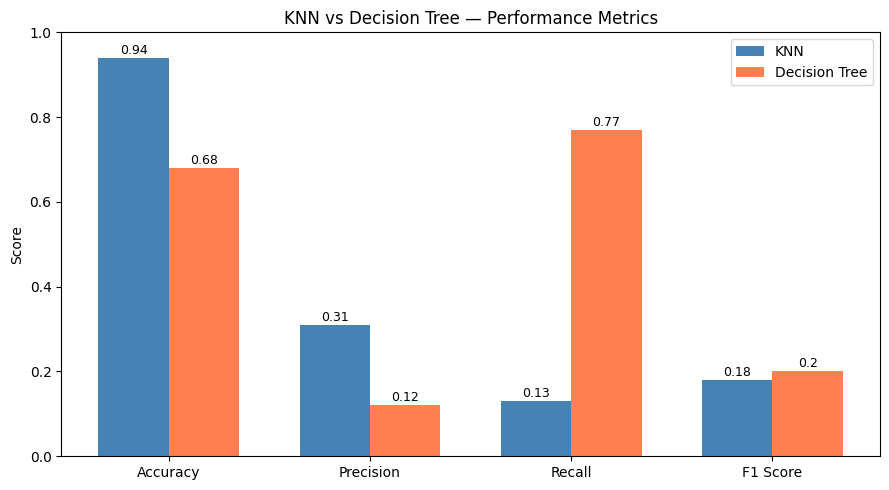

In [20]:
# ── Model Comparison Summary ──────────────────────────────
# Compare both models across all 4 metrics.
# Decision Tree has lower accuracy but much higher recall — better for our task.

comparison = pd.DataFrame({
    'Model':     ['KNN (k=5)', 'Decision Tree (depth=4)'],
    'Accuracy':  [round(accuracy_score(y_test, y_pred_knn), 2),  round(accuracy_score(y_test, y_pred_dt), 2)],
    'Precision': [round(precision_score(y_test, y_pred_knn), 2), round(precision_score(y_test, y_pred_dt), 2)],
    'Recall':    [round(recall_score(y_test, y_pred_knn), 2),    round(recall_score(y_test, y_pred_dt), 2)],
    'F1 Score':  [round(f1_score(y_test, y_pred_knn), 2),        round(f1_score(y_test, y_pred_dt), 2)]
})
print(comparison.to_string(index=False))

# ── Bar Chart ─────────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
knn_scores = [round(accuracy_score(y_test, y_pred_knn), 2),  round(precision_score(y_test, y_pred_knn), 2),
              round(recall_score(y_test, y_pred_knn), 2),    round(f1_score(y_test, y_pred_knn), 2)]
dt_scores  = [round(accuracy_score(y_test, y_pred_dt), 2),   round(precision_score(y_test, y_pred_dt), 2),
              round(recall_score(y_test, y_pred_dt), 2),     round(f1_score(y_test, y_pred_dt), 2)]

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, knn_scores, width, label='KNN', color='steelblue')
ax.bar(x + width/2, dt_scores,  width, label='Decision Tree', color='coral')
ax.set_ylabel('Score')
ax.set_title('KNN vs Decision Tree — Performance Metrics')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1); ax.legend()

# Label each bar with its value
for i, (k, d) in enumerate(zip(knn_scores, dt_scores)):
    ax.text(i - width/2, k + 0.01, str(k), ha='center', fontsize=9)
    ax.text(i + width/2, d + 0.01, str(d), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
# Section 4: Clustering Analysis

Three K-Means clustering analyses on different feature subsets to identify distinct squirrel behavioural profiles and examine their relationship with `Approaches`.

In [21]:
# Import necessary libraries for data manipulation, visualization, and clustering
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Load the merged dataset and select specific features needed for the analysis
df_master = pd.read_csv('squirrel_merged.csv')

cols_needed = [
    'X', 'Y', 'Shift',
    'Running', 'Chasing', 'Climbing', 'Eating', 'Foraging',
    'Kuks', 'Quaas', 'Tail flags', 'Tail twitches',
    'Approaches', 'Hectare_Squirrel_Count'
]
df_ready = df_master[cols_needed].copy()

# Preprocess data: encode categorical 'Shift' and boolean behavior/signal columns into numerical formats (0/1)
df_ready['Shift'] = df_ready['Shift'].map({'AM': 1, 'PM': 0})
bool_cols = ['Running','Chasing','Climbing','Eating','Foraging',
             'Kuks','Quaas','Tail flags','Tail twitches','Approaches']
df_ready[bool_cols] = df_ready[bool_cols].astype(int)

print(f"Data ready: {len(df_ready)} rows")
df_ready.head()

Data ready: 3023 rows


,X,Y,Shift,Running,Chasing,Climbing,Eating,Foraging,Kuks,Quaas,Tail flags,Tail twitches,Approaches,Hectare_Squirrel_Count
0,-73.956134,40.794082,0,0,0,0,0,0,0,0,0,0,0,3.0
1,-73.968857,40.783783,1,0,0,0,0,0,0,0,0,0,0,7.0
2,-73.974281,40.775534,0,0,1,0,0,0,0,0,0,0,0,8.0
3,-73.959641,40.790313,0,0,0,0,1,1,0,0,0,0,0,16.0
4,-73.970268,40.776213,1,0,0,0,0,1,0,0,0,0,0,13.0


## 4.1 K-Means Clustering: Behavioural & Temporal Profiling
**Features:** Running, Chasing, Climbing, Eating, Foraging, Shift

**Objective:** Group squirrels into distinct behavioural personas based on daily activity patterns.

In this section, we apply K-Means to group squirrels based on their physical activities and the time of day. 
We use the Elbow Method to find the optimal number of clusters (K).


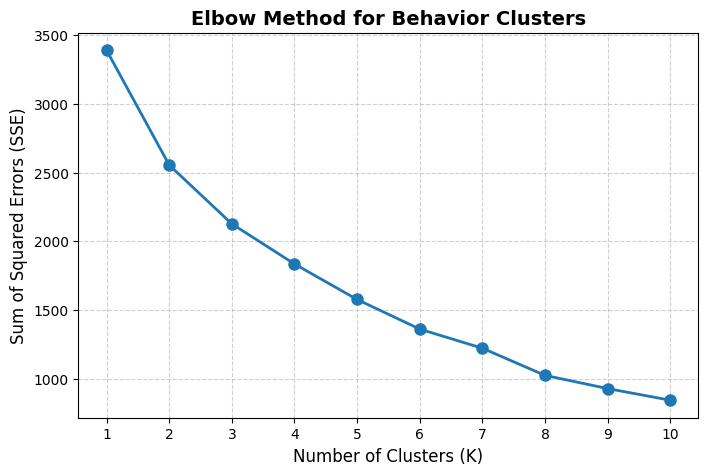

In [22]:
# Select features related to squirrel behaviors and time of day
behavior_features = ['Running', 'Chasing', 'Climbing', 'Eating', 'Foraging', 'Shift']
X_behavior = df_ready[behavior_features]

# Test K values from 1 to 10 and record the Sum of Squared Errors (SSE)
sse = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_behavior)
    sse.append(kmeans.inertia_)

# Plot the Elbow curve to see where the SSE drop slows down and find the point
plt.figure(figsize=(8, 5))
plt.plot(K_range, sse, marker='o', linestyle='-', color='#1f77b4', linewidth=2, markersize=8)
plt.title('Elbow Method for Behavior Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Sum of Squared Errors (SSE)', fontsize=12)
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [23]:
# Find two possible K value and compare K=3 vs K=5 using Silhouette Score
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df_ready['Behavior_Cluster'] = kmeans_3.fit_predict(X_behavior)

kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df_ready['Behavior_Cluster_5'] = kmeans_5.fit_predict(X_behavior)

sil_3 = silhouette_score(X_behavior, df_ready['Behavior_Cluster'])
sil_5 = silhouette_score(X_behavior, df_ready['Behavior_Cluster_5'])

# Print the scores to see which one is higher
print(f"Silhouette Score — K=3: {sil_3:.4f}")
print(f"Silhouette Score — K=5: {sil_5:.4f}")

Silhouette Score — K=3: 0.3235
Silhouette Score — K=5: 0.3919


Now that we choose K=5 and we will build a profile for each cluster using a heatmap to see 
what behaviors define them. Most importantly, we will cross-tabulate these clusters with 
the `Approaches` variable to see which squirrel group is most likely to interact with humans.


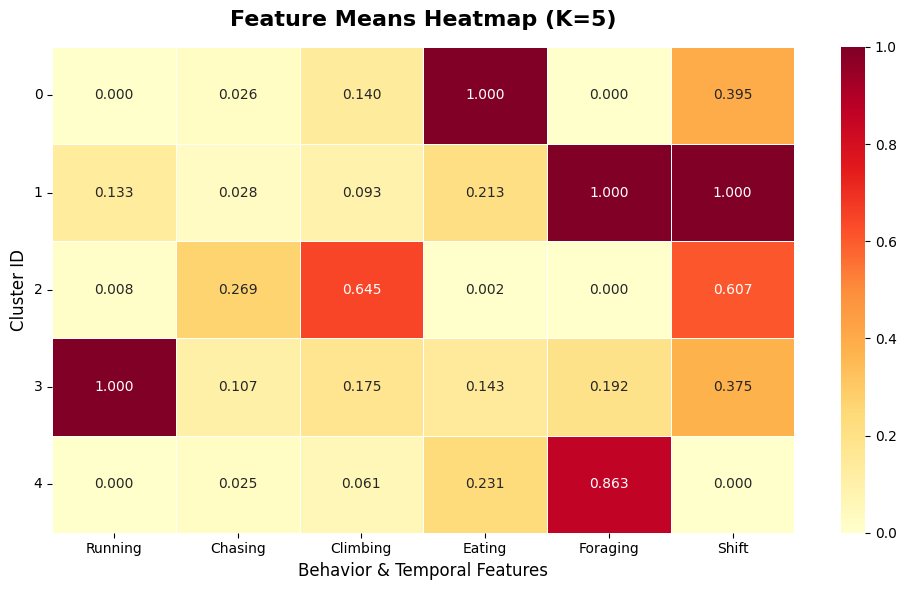


Approach rate by Behavior Cluster (K=5):
Approaches              0      1
Behavior_Cluster_5              
0                   0.926  0.074
1                   0.915  0.085
2                   0.980  0.020
3                   0.952  0.048
4                   0.930  0.070


In [24]:
# Calculate the average value of each feature for our 5 clusters
cluster_profile_5 = df_ready.groupby('Behavior_Cluster_5')[behavior_features].mean()

# Plot a heatmap to easily visualize the "personality" of each cluster
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile_5, annot=True, cmap='YlOrRd', fmt='.3f', linewidths=.5)
plt.title('Feature Means Heatmap (K=5)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Behavior & Temporal Features', fontsize=12)
plt.ylabel('Cluster ID', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Check: how often do squirrels in each group approach humans?
print("\nApproach rate by Behavior Cluster (K=5):")
cross_5 = pd.crosstab(index=df_ready['Behavior_Cluster_5'],
                      columns=df_ready['Approaches'], normalize='index')
print(cross_5.round(3))

## 4.2 K-Means Clustering: Geospatial Territory Segmentation
**Features:** X (Longitude), Y (Latitude)

**Objective:** Identify whether geographic location within Central Park predicts approach behaviour.

In this section, we focus on physical locations. We apply K-Means clustering using the GPS coordinates (Longitude X and Latitude Y) to see if squirrels naturally divide into distinct geographic zones in Central Park. First, we use the Elbow Method to find the best K.

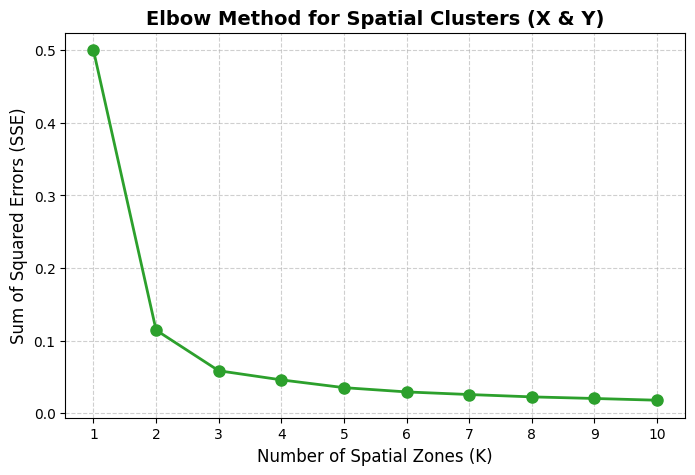

In [25]:
# Select only the GPS coordinates for spatial clustering
geo_features = ['X', 'Y']
X_geo = df_ready[geo_features]

# Test K values from 1 to 10 to find the best geographic split
sse_geo = []
for k in range(1, 11):
    kmeans_geo = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_geo.fit(X_geo)
    sse_geo.append(kmeans_geo.inertia_)

# Plot the Elbow curve to visualize the error drop for spatial clusters
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse_geo, marker='o', linestyle='-', color='#2ca02c', linewidth=2, markersize=8)
plt.title('Elbow Method for Spatial Clusters (X & Y)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Spatial Zones (K)', fontsize=12)
plt.ylabel('Sum of Squared Errors (SSE)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Similar to the behavioral clustering, we use the Silhouette Score to mathematically confirm whether a 2-zone or 3-zone split makes more sense for the park's geography.

In [26]:
# Group the spatial data into 2 zones and 3 zones
labels_2 = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_geo)
labels_3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_geo)

# Calculate and print the Silhouette Scores to see which geographic split is stronger
print(f"Silhouette Score — K=2: {silhouette_score(X_geo, labels_2):.4f}")
print(f"Silhouette Score — K=3: {silhouette_score(X_geo, labels_3):.4f}")

Silhouette Score — K=2: 0.6545
Silhouette Score — K=3: 0.5532


Now we apply K=2 to create the two spatial zones (North and South). We will visualize them on a scatter plot have a basic map of Central Park, and then check if the geographical location affects how likely squirrels are to approach humans.

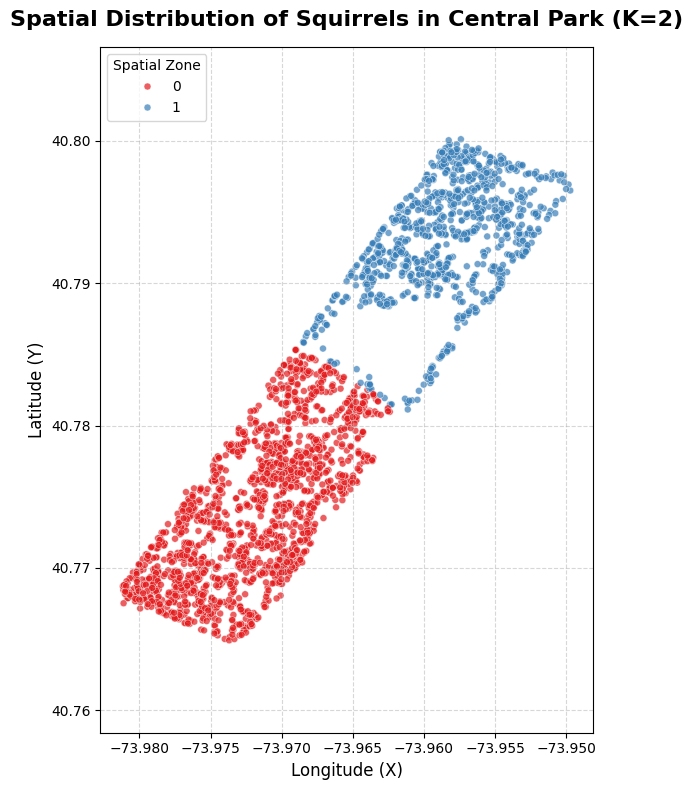


Approach rate by Spatial Zone:
Approaches       0      1
Geo_Cluster              
0            0.936  0.064
1            0.951  0.049


In [27]:
# Group the squirrels into 2 distinct spatial zones based on coordinates
kmeans_geo = KMeans(n_clusters=2, random_state=42, n_init=10)
df_ready['Geo_Cluster'] = kmeans_geo.fit_predict(X_geo)

# Plot the squirrels on a scatter plot to recreate the park map
plt.figure(figsize=(6, 8))
sns.scatterplot(data=df_ready, x='X', y='Y', hue='Geo_Cluster',
                palette='Set1', s=25, alpha=0.7)
plt.title('Spatial Distribution of Squirrels in Central Park (K=2)',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Longitude (X)', fontsize=12)
plt.ylabel('Latitude (Y)', fontsize=12)
# Keep the X and Y axis scales equal so the map doesn't look stretched
plt.axis('equal')
plt.legend(title='Spatial Zone', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Check the approach rates for the two geographic zones
print("\nApproach rate by Spatial Zone:")
cross_geo = pd.crosstab(index=df_ready['Geo_Cluster'],
                        columns=df_ready['Approaches'], normalize='index')
print(cross_geo.round(3))

## 4.3 Hierarchical Clustering: Warning Signal Hierarchy Analysis
**Features:** Kuks, Quaas, Tail flags, Tail twitches

**Objective:** Examine how vocal and physical warning signals combine into escalating threat-level profiles.

In this final clustering section, we analyze the squirrels' physical and vocal signals. Because these behaviors are quite rare, we use Agglomerative Hierarchical Clustering with the Ward method to see how these signals group together. The dendrogram below helps us visually determine the optimal number of clusters (K).

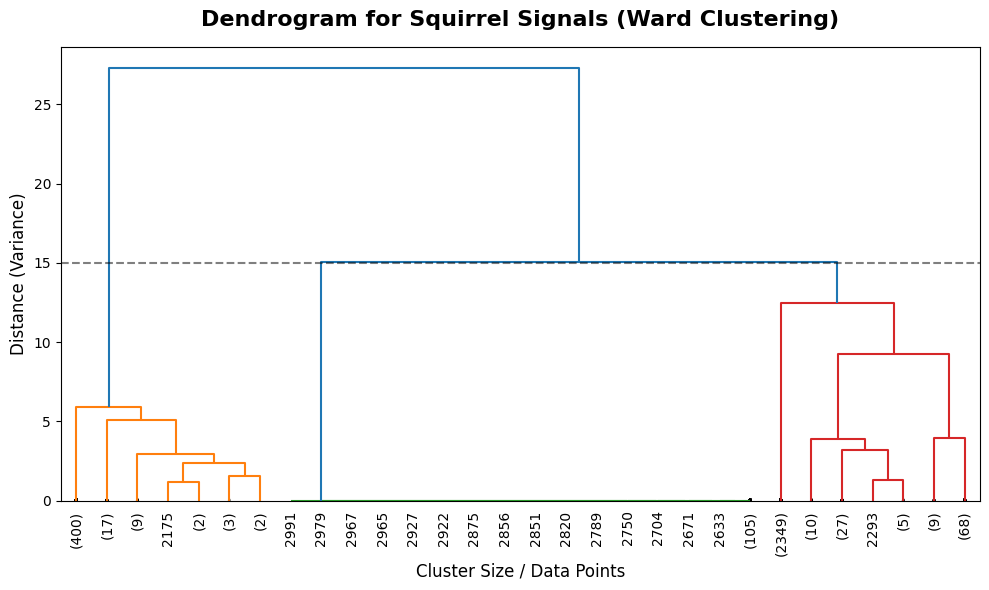

In [28]:
# Select features related to vocal and visual warning signals
signal_features = ['Kuks', 'Quaas', 'Tail flags', 'Tail twitches']
X_signal = df_ready[signal_features]

# Perform hierarchical clustering using the Ward method (minimizes variance)
Z = linkage(X_signal, method='ward')

# Plot the dendrogram to visualize the clustering hierarchy
plt.figure(figsize=(10, 6))

# Truncate the tree to show only the last 30 merges so the plot is readable
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90.,
           leaf_font_size=10., show_contracted=True, color_threshold=15)
plt.title('Dendrogram for Squirrel Signals (Ward Clustering)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Cluster Size / Data Points', fontsize=12)
plt.ylabel('Distance (Variance)', fontsize=12)

# Draw a horizontal line at distance=15 to show where we cut the tree (giving us K=3)
plt.axhline(y=15, c='k', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

Based on the dendrogram, we cut the tree to create 3 distinct signal clusters. We will now apply this grouping to our data, check what specific signals define each cluster, and finally, evaluate how these signal groups relate to a squirrel's likelihood of approaching humans.

In [29]:
# Apply Hierarchical Clustering to divide squirrels into 3 signal groups
hierarchical = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df_ready['Signal_Cluster'] = hierarchical.fit_predict(X_signal)

# Print the average feature values to understand the "profile" of each cluster
print("Signal cluster feature means:")
print(df_ready.groupby('Signal_Cluster')[signal_features].mean().round(3))

# Check how often squirrels in each signal group approach humans
print("\nApproach rate by Signal Cluster:")
cross_signal = pd.crosstab(index=df_ready['Signal_Cluster'],
                           columns=df_ready['Approaches'], normalize='index')
print(cross_signal.round(3))

Signal cluster feature means:
                 Kuks  Quaas  Tail flags  Tail twitches
Signal_Cluster                                         
0               0.036  0.017       0.006            0.0
1               0.032  0.016       0.046            1.0
2               0.000  0.000       1.000            0.0

Approach rate by Signal Cluster:
Approaches          0      1
Signal_Cluster              
0               0.945  0.055
1               0.919  0.081
2               0.942  0.058
